# 04. Estimand Cards and Causal Design Documents

Notebook 03 translated ambiguous stakeholder questions into structured causal questions. This notebook takes the next step: it turns those causal questions into estimand cards and causal design documents.

An estimand card is a compact, reviewable artifact. It says exactly what effect we want, for whom, under what treatment and comparison, over what time window, and under what assumptions. A causal design document extends the card into a plan for data, diagnostics, estimation, sensitivity analysis, and reporting.

The AI role in this notebook is deliberately bounded. We use models to draft and stress-test design artifacts, not to declare whether an intervention worked.


## Mathematical Core

An estimand card should make the target quantity explicit. A compact template is

$$
\theta = \mathbb{E}_{i \in \mathcal{P}}[Y_i(a_1) - Y_i(a_0)],
$$

with population $\mathcal{P}$, intervention levels $a_1$ and $a_0$, outcome $Y$, and timing all specified. Identification then asks whether an observed-data functional $\psi(P)$ equals $\theta$ under the stated assumptions,

$$
\theta = \psi(P_{\mathrm{observed}}).
$$

The design document is useful when every later modeling choice can be traced back to this equality. If the document does not say which assumptions make $\theta$ equal to an estimable quantity, the analysis is still underspecified.


## Learning Goals

By the end of this notebook, you should be able to:

- distinguish a causal question from an estimand;
- write an estimand card that makes unit, population, treatment, comparison, outcome, timing, and estimand type explicit;
- explain why ATE, ATT, CATE, policy value, and LATE answer different business questions;
- convert an estimand card into a causal design document;
- use simulation to show how the chosen estimand changes the numerical target;
- use an LLM as a design-document drafter while keeping validation and human review in the loop;
- compare local models on structured-output reliability and causal-design quality.


## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference requires validation, audit trails, and analyst judgment.

Treat model output as a draft artifact, not as causal evidence. A model may produce valid JSON with weak causal reasoning, or strong prose that fails schema validation.

When live calls are enabled, read the results as experiments about AI behavior:

- Did the model invent design details?
- Did it confuse prediction with causation?
- Did it recommend bad controls?
- Did it obey the schema?
- Did it surface missing information?
- Did it preserve uncertainty?

The goal is not to make every model output perfect. The goal is to learn how to build AI-assisted causal workflows that are auditable, constrained, and reviewed by a human analyst.

## 1. Setup


In [26]:
import gc
import importlib.util
import json
import re
import textwrap
from functools import lru_cache
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field, ValidationError

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

from notebooks._shared.display import smart_display


In [27]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 900
TEMPERATURE = 0.0
SEED = 321

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]


In [28]:
# Section focus: 1. Setup.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

def has_package(module_name):
    """Carry out the has package step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    module_name : object
        Name of the Python package or notebook module being checked for availability.
    
    Returns
    -------
    object
        Intermediate result produced by the has package calculation and reused by later cells.
    """
    return importlib.util.find_spec(module_name) is not None

runtime_status = pd.DataFrame(
    [
        ('torch', torch.__version__),
        ('cuda available', torch.cuda.is_available()),
        ('cuda device count', torch.cuda.device_count()),
        ('accelerate installed', has_package('accelerate')),
        ('transformers installed', has_package('transformers')),
        ('torchvision installed', has_package('torchvision')),
    ],
    columns=['check', 'value'],
)

smart_display(runtime_status)


,check,value
0,torch,2.11.0+cu130
1,cuda available,True
2,cuda device count,1
3,accelerate installed,True
4,transformers installed,True
5,torchvision installed,True


## 2. From a Causal Question to an Estimand

A causal question names the intervention and outcome. An estimand names the exact mathematical target.

The difference matters. Consider the question:

> Did proactive outreach reduce churn?

That question is not enough. We still need to know whether the business wants:

- the effect if every eligible account received outreach;
- the effect among accounts that actually received outreach;
- the effect for high-risk accounts only;
- the value of a policy that assigns outreach only when predicted risk exceeds a threshold;
- the effect for accounts whose treatment status was changed by an encouragement or instrument.

Each target can be reasonable. They are not interchangeable.


| estimand | full name | question answered | typical industry use |
|---|---|---|---|
| ATE | Average treatment effect | What if everyone eligible received treatment versus comparison? | scale a treatment to the full eligible population |
| ATT | Average treatment effect on the treated | What was the effect for units that actually received treatment? | evaluate a targeted operational program |
| ATC | Average treatment effect on the controls | What would happen if currently untreated units received treatment? | decide whether to expand to untreated units |
| CATE | Conditional average treatment effect | How does the effect vary by segment, risk, context, or need? | personalize assignment or understand heterogeneity |
| Policy value | Expected outcome under an assignment rule | What outcome would a proposed policy produce? | choose between decision rules |
| LATE | Local average treatment effect | What is the effect for units whose treatment changed because of an instrument? | analyze encouragement, eligibility, or threshold designs |


### Potential-Outcome Notation

Let $Y_i(1)$ be the potential outcome for unit $i$ under treatment and $Y_i(0)$ be the potential outcome under comparison. Let $T_i$ indicate the treatment actually received, and let $X_i$ contain pre-treatment covariates.

A few common estimands are:

$$
ATE = E[Y(1) - Y(0)]
$$

$$
ATT = E[Y(1) - Y(0) \mid T = 1]
$$

$$
CATE(x) = E[Y(1) - Y(0) \mid X = x]
$$

A design document should say which one is being targeted before anyone writes an estimator.


## 3. Anatomy of an Estimand Card


| field | purpose | example |
|---|---|---|
| card_id | Stable identifier for versioning | retention_q2_ate_v1 |
| decision | Business action this evidence will inform | scale, stop, redesign, target, or monitor |
| unit | Object receiving treatment and contributing an outcome | account, user, session, store, ticket |
| target_population | Population the effect is about | eligible active accounts during Q2 |
| eligibility_rule | Rule that defines inclusion before treatment | active accounts with renewal date after outreach start |
| treatment | Intervention or exposure | proactive success-manager outreach |
| comparison | Counterfactual condition | standard reactive support |
| time_zero | When follow-up begins | date account becomes eligible for outreach |
| outcome | Primary business metric and measurement window | 90-day churn after eligibility |
| estimand_type | ATE, ATT, CATE, policy value, LATE, etc. | ATT if evaluating targeted treated accounts |
| identification_strategy | How the causal contrast could be identified | randomized rollout, adjustment, DiD, RD, IV |
| assumptions | Conditions needed for causal interpretation | exchangeability, positivity, consistency, no interference |
| diagnostics | Evidence that the design is plausible | overlap, balance, pre-trends, manipulation checks |
| no_go_conditions | Findings that invalidate or pause the analysis | poor overlap, missing assignment logs, outcome redefinition |


## 4. Structured Estimand Cards

The schema below is intentionally stricter than a prose memo. That is the point. A model can write a convincing paragraph while forgetting the target population, time zero, or comparison condition. A structured card gives us something to validate.


In [31]:
# Section focus: 4. Structured Estimand Cards.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class OutcomeSpec(BaseModel):
    name: str
    measurement: str
    window: str
    direction: str
    guardrail: bool = False


class EstimandCard(BaseModel):
    card_id: str
    stakeholder_question: str
    decision: str
    unit: str
    target_population: str
    eligibility_rule: str
    treatment: str
    comparison: str
    time_zero: str
    primary_outcome: OutcomeSpec
    guardrail_outcomes: list[OutcomeSpec] = Field(default_factory=list)
    estimand_type: Literal['ATE', 'ATT', 'ATC', 'CATE', 'policy value', 'LATE', 'event-study effect']
    estimand_expression: str
    identification_strategy: str
    assignment_mechanism: str
    required_assumptions: list[str] = Field(min_length=1)
    threats_to_validity: list[str] = Field(default_factory=list)
    data_requirements: list[str] = Field(default_factory=list)
    diagnostics: list[str] = Field(default_factory=list)
    no_go_conditions: list[str] = Field(default_factory=list)
    decision_rule: str


class CausalDesignDocument(BaseModel):
    document_id: str
    card: EstimandCard
    design_summary: str
    identification_plan: list[str]
    data_plan: list[str]
    diagnostic_plan: list[str]
    sensitivity_plan: list[str]
    reporting_plan: list[str]
    open_questions_for_stakeholders: list[str]


## 5. Example Estimand Cards


In [32]:
# Section focus: 5. Example Estimand Cards.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

card_records = [
    {
        'card_id': 'retention_outreach_att_v1',
        'stakeholder_question': 'Did proactive customer-success outreach reduce churn?',
        'decision': 'Decide whether to continue and refine targeted outreach for high-risk accounts.',
        'unit': 'customer account',
        'target_population': 'active SaaS accounts that were eligible for customer-success outreach during the quarter',
        'eligibility_rule': 'account was active, had at least 30 days of prior usage history, and had not already submitted cancellation',
        'treatment': 'receiving proactive customer-success outreach during the intervention month',
        'comparison': 'not receiving proactive outreach during the same eligibility window',
        'time_zero': 'date the account became eligible for outreach assignment',
        'primary_outcome': {
            'name': '90-day churn',
            'measurement': 'indicator that the account cancels or fails to renew within 90 days after time zero',
            'window': '0 to 90 days after eligibility date',
            'direction': 'lower is better',
            'guardrail': False,
        },
        'guardrail_outcomes': [
            {'name': 'support burden', 'measurement': 'tickets per account in 90 days', 'window': '0 to 90 days', 'direction': 'lower is better', 'guardrail': True},
            {'name': 'expansion revenue', 'measurement': 'net expansion revenue within 90 days', 'window': '0 to 90 days', 'direction': 'higher is better', 'guardrail': True},
        ],
        'estimand_type': 'ATT',
        'estimand_expression': 'E[Y(1) - Y(0) | T = 1, eligible = 1]',
        'identification_strategy': 'observational adjustment using pre-treatment account risk, usage, tenure, plan, region, and support history',
        'assignment_mechanism': 'customer-success managers targeted accounts using health scores and operational judgment',
        'required_assumptions': [
            'all common causes of outreach assignment and churn are measured before outreach',
            'eligible accounts have overlap in the probability of outreach after conditioning on covariates',
            'outreach for one account does not materially change another account churn outcome',
        ],
        'threats_to_validity': [
            'managers may know unlogged renewal risk',
            'post-outreach usage must not be adjusted for as a confounder',
            'enterprise accounts may have poor overlap with small accounts',
        ],
        'data_requirements': [
            'eligibility table anchored before outreach',
            'outreach timestamp and owner',
            'pre-treatment usage, tickets, plan, tenure, renewal timing, and health score',
            'churn outcome measured over 90 days',
        ],
        'diagnostics': [
            'overlap of propensity scores',
            'balance on pre-treatment covariates after weighting or matching',
            'negative-control outcome if available',
        ],
        'no_go_conditions': [
            'outreach timestamp missing for many treated accounts',
            'treated accounts have no comparable untreated accounts in key segments',
            'churn definition changed during the analysis window',
        ],
        'decision_rule': 'continue the program only if estimated churn reduction is practically meaningful and guardrails do not worsen materially',
    },
    {
        'card_id': 'ranking_model_ate_v1',
        'stakeholder_question': 'Did the new ranking model increase marketplace conversion?',
        'decision': 'Decide whether to keep the new ranking model as the default experience.',
        'unit': 'user search session',
        'target_population': 'eligible marketplace search sessions that could have been assigned either ranking model',
        'eligibility_rule': 'session was logged after experiment start, had a valid query, and belonged to an eligible market and device type',
        'treatment': 'assignment to the new ranking model at session start',
        'comparison': 'assignment to the previous ranking model at session start',
        'time_zero': 'session ranking assignment time',
        'primary_outcome': {
            'name': 'session conversion',
            'measurement': 'indicator that the user completes a purchase within the attribution window',
            'window': 'same session plus 24-hour attribution window',
            'direction': 'higher is better',
            'guardrail': False,
        },
        'guardrail_outcomes': [
            {'name': 'seller concentration', 'measurement': 'share of impressions received by top sellers', 'window': 'experiment window', 'direction': 'no harmful increase', 'guardrail': True},
            {'name': 'latency', 'measurement': 'p95 ranking service latency', 'window': 'experiment window', 'direction': 'lower is better', 'guardrail': True},
        ],
        'estimand_type': 'ATE',
        'estimand_expression': 'E[Y(1) - Y(0) | eligible session = 1]',
        'identification_strategy': 'session-level randomized experiment with pre-specified guardrails',
        'assignment_mechanism': 'traffic allocation service randomized eligible sessions between old and new ranking models',
        'required_assumptions': [
            'randomization was implemented as logged',
            'sessions are analyzed according to assignment rather than post-treatment exposure intensity',
            'interference across users and sellers is negligible or monitored as a marketplace guardrail',
        ],
        'threats_to_validity': [
            'triggering logic may exclude non-random subsets of sessions',
            'seller-side interference may change inventory exposure',
            'latency changes may affect conversion independently of ranking quality',
        ],
        'data_requirements': [
            'assignment logs',
            'eligibility logs',
            'query and market metadata measured before assignment',
            'conversion events and attribution window',
            'latency and seller exposure logs',
        ],
        'diagnostics': [
            'sample ratio mismatch check',
            'balance on pre-treatment query, market, device, and user-history fields',
            'guardrail monitoring for seller concentration and latency',
        ],
        'no_go_conditions': [
            'assignment is missing for a large share of sessions',
            'sample ratio mismatch indicates randomization failure',
            'guardrail harm exceeds launch threshold',
        ],
        'decision_rule': 'ship only if conversion lift exceeds the minimum detectable business threshold and guardrails remain acceptable',
    },
    {
        'card_id': 'ai_support_policy_value_v1',
        'stakeholder_question': 'Should we roll out the AI support assistant to all queues?',
        'decision': 'Choose whether to expand assistant coverage and under what guardrails.',
        'unit': 'support queue-day',
        'target_population': 'support queues eligible for assistant deployment during the rollout period',
        'eligibility_rule': 'queue had stable routing, sufficient historical ticket volume, and no concurrent major process redesign',
        'treatment': 'assistant enabled for triage and first-draft responses',
        'comparison': 'standard support workflow without assistant enablement',
        'time_zero': 'date assistant is enabled for an eligible queue',
        'primary_outcome': {
            'name': 'ticket resolution workload',
            'measurement': 'human-handled tickets per queue-day, adjusted for incoming demand',
            'window': '14 to 60 days after enablement',
            'direction': 'lower is better',
            'guardrail': False,
        },
        'guardrail_outcomes': [
            {'name': 'reopen rate', 'measurement': 'share of resolved tickets reopened within 7 days', 'window': '0 to 67 days after enablement', 'direction': 'lower is better', 'guardrail': True},
            {'name': 'customer satisfaction', 'measurement': 'post-resolution CSAT score', 'window': '0 to 60 days after enablement', 'direction': 'higher is better', 'guardrail': True},
        ],
        'estimand_type': 'policy value',
        'estimand_expression': 'E[Y under assistant-rollout policy] - E[Y under no-assistant policy] for eligible queue-days',
        'identification_strategy': 'staggered rollout design if timing is plausibly independent after controls; otherwise targeted experiment recommended',
        'assignment_mechanism': 'deployment prioritized by operational readiness and queue volume',
        'required_assumptions': [
            'rollout timing is not driven by unmeasured demand shocks after conditioning on queue history',
            'ticket definitions and deflection logging remain stable after assistant deployment',
            'spillovers across queues are either limited or explicitly modeled',
        ],
        'threats_to_validity': [
            'assistant may deflect tickets instead of reducing underlying customer problems',
            'queues selected early may be more mature or better staffed',
            'quality harms may appear after workload improvements',
        ],
        'data_requirements': [
            'queue-level rollout dates',
            'queue eligibility and exclusion rules',
            'incoming demand, resolved tickets, deflected tickets, staffing, backlog, and routing changes',
            'quality guardrails including reopen rate and CSAT',
        ],
        'diagnostics': [
            'pre-rollout trends in volume and quality',
            'balance of early and late queues on pre-treatment metrics',
            'sensitivity to excluding concurrent process-change periods',
        ],
        'no_go_conditions': [
            'deflected tickets are not logged',
            'rollout coincides with a major routing redesign',
            'quality guardrails cannot be measured consistently',
        ],
        'decision_rule': 'expand only if workload falls without evidence of worse reopen rates, CSAT, or hidden deflection',
    },
]

estimand_cards = [EstimandCard.model_validate(record) for record in card_records]

card_summary = pd.DataFrame(
    [
        {
            'card_id': card.card_id,
            'estimand_type': card.estimand_type,
            'unit': card.unit,
            'primary_outcome': card.primary_outcome.name,
            'identification_strategy': card.identification_strategy,
        }
        for card in estimand_cards
    ]
)

smart_display(card_summary)


,card_id,estimand_type,unit,primary_outcome,identification_strategy
0,retention_outreach_att_v1,ATT,customer account,90-day churn,"observational adjustment using pre-treatment account risk, usage, tenure, plan, region, and support history"
1,ranking_model_ate_v1,ATE,user search session,session conversion,session-level randomized experiment with pre-specified guardrails
2,ai_support_policy_value_v1,policy value,support queue-day,ticket resolution workload,staggered rollout design if timing is plausibly independent after controls; otherwise targeted experiment recommended


Notice how the cards make choices that the original questions left implicit.

The retention card uses ATT because the business is evaluating a targeted program that already happened. The ranking card uses ATE because the randomized experiment concerns the eligible session population. The AI support card uses policy value because the decision is about a rollout rule and operational guardrails alongside a one-time treatment contrast.

Those choices are not cosmetic. They decide which units enter the analysis, which assumptions are needed, which diagnostics matter, and how the result will be interpreted.


## 6. Rendering an Estimand Card for Review


In [33]:
# Section focus: 6. Rendering an Estimand Card for Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def bullet_list(items):
    """Carry out the bullet list step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    items : object
        The items setting that controls the bullet list calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the bullet list calculation and reused by later cells.
    """
    return '\n'.join(f'- {item}' for item in items)


def render_estimand_card(card):
    """Render estimand card for display in the 04. Estimand Cards and Causal Design Documents notebook.
    
    Parameters
    ----------
    card : object
        Structured estimand or design card being generated, checked, or displayed.
    
    Returns
    -------
    object
        Intermediate result produced by the estimand card calculation and reused by later cells.
    """
    guardrails = '\n'.join(
        f'- **{outcome.name}** ({outcome.window}): {outcome.measurement}; direction: {outcome.direction}'
        for outcome in card.guardrail_outcomes
    ) or '- None specified'

    return f'''
### Estimand Card: `{card.card_id}`

**Stakeholder question.** {card.stakeholder_question}

**Decision.** {card.decision}

**Unit and population.** The unit is `{card.unit}`. The target population is {card.target_population}.

**Eligibility rule.** {card.eligibility_rule}

**Treatment.** {card.treatment}

**Comparison.** {card.comparison}

**Time zero.** {card.time_zero}

**Primary outcome.** {card.primary_outcome.name}: {card.primary_outcome.measurement}. Window: {card.primary_outcome.window}. Direction: {card.primary_outcome.direction}.

**Guardrail outcomes.**
{guardrails}

**Estimand.** {card.estimand_type}: `{card.estimand_expression}`

**Identification strategy.** {card.identification_strategy}

**Assignment mechanism.** {card.assignment_mechanism}

**Required assumptions.**
{bullet_list(card.required_assumptions)}

**Threats to validity.**
{bullet_list(card.threats_to_validity)}

**Data requirements.**
{bullet_list(card.data_requirements)}

**Diagnostics.**
{bullet_list(card.diagnostics)}

**No-go conditions.**
{bullet_list(card.no_go_conditions)}

**Decision rule.** {card.decision_rule}
'''.strip()


smart_display(Markdown(render_estimand_card(estimand_cards[0])))


### Estimand Card: `retention_outreach_att_v1`

**Stakeholder question.** Did proactive customer-success outreach reduce churn?

**Decision.** Decide whether to continue and refine targeted outreach for high-risk accounts.

**Unit and population.** The unit is `customer account`. The target population is active SaaS accounts that were eligible for customer-success outreach during the quarter.

**Eligibility rule.** account was active, had at least 30 days of prior usage history, and had not already submitted cancellation

**Treatment.** receiving proactive customer-success outreach during the intervention month

**Comparison.** not receiving proactive outreach during the same eligibility window

**Time zero.** date the account became eligible for outreach assignment

**Primary outcome.** 90-day churn: indicator that the account cancels or fails to renew within 90 days after time zero. Window: 0 to 90 days after eligibility date. Direction: lower is better.

**Guardrail outcomes.**
- **support burden** (0 to 90 days): tickets per account in 90 days; direction: lower is better
- **expansion revenue** (0 to 90 days): net expansion revenue within 90 days; direction: higher is better

**Estimand.** ATT: `E[Y(1) - Y(0) | T = 1, eligible = 1]`

**Identification strategy.** observational adjustment using pre-treatment account risk, usage, tenure, plan, region, and support history

**Assignment mechanism.** customer-success managers targeted accounts using health scores and operational judgment

**Required assumptions.**
- all common causes of outreach assignment and churn are measured before outreach
- eligible accounts have overlap in the probability of outreach after conditioning on covariates
- outreach for one account does not materially change another account churn outcome

**Threats to validity.**
- managers may know unlogged renewal risk
- post-outreach usage must not be adjusted for as a confounder
- enterprise accounts may have poor overlap with small accounts

**Data requirements.**
- eligibility table anchored before outreach
- outreach timestamp and owner
- pre-treatment usage, tickets, plan, tenure, renewal timing, and health score
- churn outcome measured over 90 days

**Diagnostics.**
- overlap of propensity scores
- balance on pre-treatment covariates after weighting or matching
- negative-control outcome if available

**No-go conditions.**
- outreach timestamp missing for many treated accounts
- treated accounts have no comparable untreated accounts in key segments
- churn definition changed during the analysis window

**Decision rule.** continue the program only if estimated churn reduction is practically meaningful and guardrails do not worsen materially

This result sits between model performance and the operating policy. The useful reading is which metric would change the action in Rendering an Estimand Card for Review. Conflicting metrics are a cue to name the decision priority before choosing a rule.


## 7. From Estimand Card to Causal Design Document


In [34]:
# Section focus: 7. From Estimand Card to Causal Design Document.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def design_document_from_card(card):
    """Carry out the design document from card step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    card : object
        Structured estimand or design card being generated, checked, or displayed.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the design document from card workflow for later analysis.
    """
    document = {
        'document_id': card.card_id.replace('_v1', '_design_doc_v1'),
        'card': card.model_dump(),
        'design_summary': (
            f'This design evaluates {card.estimand_type} for {card.treatment} versus {card.comparison} '
            f'on {card.primary_outcome.name} among {card.target_population}.'
        ),
        'identification_plan': [
            f'Use the stated strategy: {card.identification_strategy}.',
            f'Anchor time zero at: {card.time_zero}.',
            'Avoid adjusting for variables measured after time zero.',
            'Document why each required assumption is plausible or not plausible.',
        ],
        'data_plan': card.data_requirements,
        'diagnostic_plan': card.diagnostics,
        'sensitivity_plan': [
            'Compare results across plausible covariate sets defined before treatment.',
            'Run segment analyses only when segments are pre-specified or clearly exploratory.',
            'Report how conclusions change under weaker assumptions or excluded edge cases.',
        ],
        'reporting_plan': [
            'Report the estimand before the estimator.',
            'Show effect size, uncertainty, target population, and limitations together.',
            'Separate primary outcome conclusions from guardrail checks.',
        ],
        'open_questions_for_stakeholders': [
            'Is this the decision-relevant population?',
            'Is the comparison condition operationally meaningful?',
            'What effect size is large enough to change the decision?',
            'Which guardrail harms would block launch even if the primary outcome improves?',
        ],
    }
    return CausalDesignDocument.model_validate(document)


design_docs = [design_document_from_card(card) for card in estimand_cards]

design_doc_summary = pd.DataFrame(
    [
        {
            'document_id': doc.document_id,
            'card_id': doc.card.card_id,
            'identification_steps': len(doc.identification_plan),
            'data_items': len(doc.data_plan),
            'diagnostics': len(doc.diagnostic_plan),
            'open_questions': len(doc.open_questions_for_stakeholders),
        }
        for doc in design_docs
    ]
)

smart_display(design_doc_summary)


,document_id,card_id,identification_steps,data_items,diagnostics,open_questions
0,retention_outreach_att_design_doc_v1,retention_outreach_att_v1,4,4,3,4
1,ranking_model_ate_design_doc_v1,ranking_model_ate_v1,4,5,3,4
2,ai_support_policy_value_design_doc_v1,ai_support_policy_value_v1,4,4,3,4


These numbers translate model behavior into decision consequences. For From Estimand Card to Causal Design Document, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


In [35]:
# Section focus: 7. From Estimand Card to Causal Design Document.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def render_design_document(doc):
    """Render design document for display in the 04. Estimand Cards and Causal Design Documents notebook.
    
    Parameters
    ----------
    doc : object
        The doc setting that controls the design document calculation in this notebook.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the design document workflow for later analysis.
    """
    return f'''
### Causal Design Document: `{doc.document_id}`

**Design summary.** {doc.design_summary}

**Identification plan.**
{bullet_list(doc.identification_plan)}

**Data plan.**
{bullet_list(doc.data_plan)}

**Diagnostic plan.**
{bullet_list(doc.diagnostic_plan)}

**Sensitivity plan.**
{bullet_list(doc.sensitivity_plan)}

**Reporting plan.**
{bullet_list(doc.reporting_plan)}

**Open questions for stakeholders.**
{bullet_list(doc.open_questions_for_stakeholders)}
'''.strip()


smart_display(Markdown(render_design_document(design_docs[2])))


### Causal Design Document: `ai_support_policy_value_design_doc_v1`

**Design summary.** This design evaluates policy value for assistant enabled for triage and first-draft responses versus standard support workflow without assistant enablement on ticket resolution workload among support queues eligible for assistant deployment during the rollout period.

**Identification plan.**
- Use the stated strategy: staggered rollout design if timing is plausibly independent after controls; otherwise targeted experiment recommended.
- Anchor time zero at: date assistant is enabled for an eligible queue.
- Avoid adjusting for variables measured after time zero.
- Document why each required assumption is plausible or not plausible.

**Data plan.**
- queue-level rollout dates
- queue eligibility and exclusion rules
- incoming demand, resolved tickets, deflected tickets, staffing, backlog, and routing changes
- quality guardrails including reopen rate and CSAT

**Diagnostic plan.**
- pre-rollout trends in volume and quality
- balance of early and late queues on pre-treatment metrics
- sensitivity to excluding concurrent process-change periods

**Sensitivity plan.**
- Compare results across plausible covariate sets defined before treatment.
- Run segment analyses only when segments are pre-specified or clearly exploratory.
- Report how conclusions change under weaker assumptions or excluded edge cases.

**Reporting plan.**
- Report the estimand before the estimator.
- Show effect size, uncertainty, target population, and limitations together.
- Separate primary outcome conclusions from guardrail checks.

**Open questions for stakeholders.**
- Is this the decision-relevant population?
- Is the comparison condition operationally meaningful?
- What effect size is large enough to change the decision?
- Which guardrail harms would block launch even if the primary outcome improves?

For From Estimand Card to Causal Design Document, the table matters because it turns several options into a decision comparison. The row that changes a threshold or review priority deserves the closest look.


## 8. Code Example: The Estimand Changes the Target

Now we simulate a targeted retention program. Accounts with higher baseline churn risk are more likely to receive outreach. The treatment effect is also stronger for high-risk accounts.

This is common in industry. Teams target interventions where they expect the biggest benefit. That means the effect among treated units can differ from the effect among all eligible units.


In [36]:
# Section focus: 8. Code Example: The Estimand Changes the Target.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


rng = np.random.default_rng(SEED)
n = 25000

segment_enterprise = rng.binomial(1, 0.32, size=n)
prior_usage = rng.normal(0, 1, size=n)
prior_tickets = rng.poisson(lam=np.exp(0.25 + 0.35 * segment_enterprise), size=n)
renewal_pressure = rng.normal(0, 1, size=n)

baseline_churn_prob = sigmoid(
    -1.25
    + 0.55 * segment_enterprise
    - 0.45 * prior_usage
    + 0.12 * prior_tickets
    + 0.35 * renewal_pressure
)

propensity = sigmoid(
    -0.85
    + 2.4 * baseline_churn_prob
    + 0.55 * segment_enterprise
    + 0.15 * prior_tickets
)

treated = rng.binomial(1, propensity)
true_risk_reduction = 0.035 + 0.16 * baseline_churn_prob + 0.025 * segment_enterprise
churn_if_control_prob = baseline_churn_prob
churn_if_treated_prob = np.clip(churn_if_control_prob - true_risk_reduction, 0.01, 0.95)
observed_churn = rng.binomial(1, np.where(treated == 1, churn_if_treated_prob, churn_if_control_prob))

retention_df = pd.DataFrame(
    {
        'segment_enterprise': segment_enterprise,
        'prior_usage': prior_usage,
        'prior_tickets': prior_tickets,
        'renewal_pressure': renewal_pressure,
        'baseline_churn_prob': baseline_churn_prob,
        'propensity': propensity,
        'treated': treated,
        'churn_if_control_prob': churn_if_control_prob,
        'churn_if_treated_prob': churn_if_treated_prob,
        'true_effect_prob': churn_if_treated_prob - churn_if_control_prob,
        'observed_churn': observed_churn,
    }
)

retention_df.head()


,segment_enterprise,prior_usage,prior_tickets,renewal_pressure,baseline_churn_prob,propensity,treated,churn_if_control_prob,churn_if_treated_prob,true_effect_prob,observed_churn
0,0,0.653,1,0.793,0.241,0.470,1,0.241,0.168,-0.074,0
1,1,-0.368,0,0.283,0.393,0.655,1,0.393,0.270,-0.123,0
2,0,0.117,0,1.880,0.344,0.494,0,0.344,0.254,-0.090,0
3,1,-0.039,5,0.658,0.537,0.851,1,0.537,0.391,-0.146,1
4,0,0.291,1,-0.620,0.186,0.437,0,0.186,0.121,-0.065,0


The table is useful because the main choices are visible at once. For Code Example: The Estimand Changes the Target, the important reading is the pattern across rows, the pattern across rows together with the largest values. That pattern should guide the next diagnostic or policy revision.


In [37]:
# Section focus: 8. Code Example: The Estimand Changes the Target.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

true_ate = retention_df['true_effect_prob'].mean()
true_att = retention_df.loc[retention_df['treated'] == 1, 'true_effect_prob'].mean()
true_atc = retention_df.loc[retention_df['treated'] == 0, 'true_effect_prob'].mean()

naive_difference = (
    retention_df.loc[retention_df['treated'] == 1, 'observed_churn'].mean()
    - retention_df.loc[retention_df['treated'] == 0, 'observed_churn'].mean()
)

ipw_ate = np.mean(
    retention_df['treated'] * retention_df['observed_churn'] / retention_df['propensity']
    - (1 - retention_df['treated']) * retention_df['observed_churn'] / (1 - retention_df['propensity'])
)

estimand_result_table = pd.DataFrame(
    [
        ('True ATE', true_ate, 'Effect if outreach were assigned to every eligible account'),
        ('True ATT', true_att, 'Effect among accounts that actually received outreach'),
        ('True ATC', true_atc, 'Effect among accounts that did not receive outreach'),
        ('Naive observed difference', naive_difference, 'Observed treated-control churn difference without adjustment'),
        ('IPW estimate of ATE', ipw_ate, 'Weighted estimate using the known assignment propensity'),
    ],
    columns=['quantity', 'risk difference', 'interpretation'],
)

smart_display(estimand_result_table)


,quantity,risk difference,interpretation
0,True ATE,-0.092,Effect if outreach were assigned to every eligible account
1,True ATT,-0.098,Effect among accounts that actually received outreach
2,True ATC,-0.084,Effect among accounts that did not receive outreach
3,Naive observed difference,-0.038,Observed treated-control churn difference without adjustment
4,IPW estimate of ATE,-0.089,Weighted estimate using the known assignment propensity


The table gives the analyst a concrete checklist rather than a loose narrative. For Code Example: The Estimand Changes the Target, the important reading is the pattern across rows, the pattern across rows together with the largest values. A pattern with practical value should change the next inspection step.


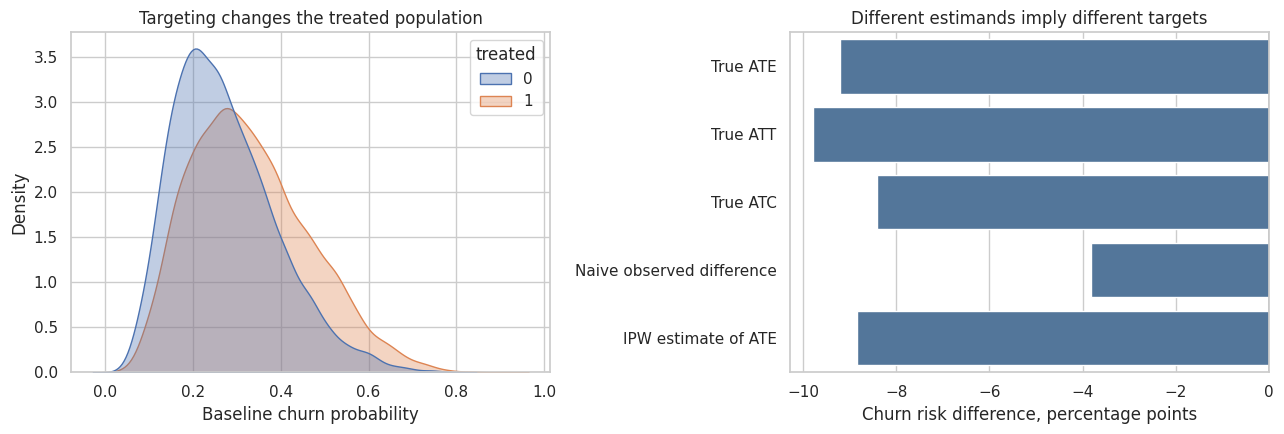

In [38]:
# Section focus: 8. Code Example: The Estimand Changes the Target.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    data=retention_df,
    x='baseline_churn_prob',
    hue='treated',
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title('Targeting changes the treated population')
axes[0].set_xlabel('Baseline churn probability')
axes[0].set_ylabel('Density')

plot_df = estimand_result_table.copy()
plot_df['risk difference pp'] = 100 * plot_df['risk difference']
sns.barplot(data=plot_df, y='quantity', x='risk difference pp', color='#4776A6', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Different estimands imply different targets')
axes[1].set_xlabel('Churn risk difference, percentage points')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


The treatment effect is negative because the outcome is churn and lower churn is better. The true ATT is more negative than the true ATE because the program targeted higher-risk accounts, and in this simulation higher-risk accounts benefit more from outreach.

The naive observed difference is not the causal effect. Treated accounts started with higher churn risk. A simple treated-control comparison mixes the effect of outreach with the targeting rule that sent outreach to riskier accounts.

The estimand card prevents a subtle mistake: if leadership asks whether the targeted program worked, ATT may be the right first target. If leadership asks whether everyone eligible should receive outreach, ATE or policy value is more relevant.


## 9. Auditing Estimand Cards


In [39]:
# Section focus: 9. Auditing Estimand Cards.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def has_text(value):
    """Carry out the has text step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the has text workflow.
    """
    return isinstance(value, str) and bool(value.strip())


def score_estimand_card(card):
    """Score estimand card for the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    card : object
        Structured estimand or design card being generated, checked, or displayed.
    
    Returns
    -------
    object
        Intermediate result produced by the estimand card calculation and reused by later cells.
    """
    checks = {
        'decision linked to action': has_text(card.decision) and any(token in card.decision.lower() for token in ['decide', 'choose', 'continue', 'ship', 'expand', 'roll out', 'scale']),
        'unit explicit': has_text(card.unit),
        'population explicit': has_text(card.target_population),
        'eligibility anchored before treatment': has_text(card.eligibility_rule),
        'treatment explicit': has_text(card.treatment),
        'comparison explicit': has_text(card.comparison),
        'time zero explicit': has_text(card.time_zero),
        'primary outcome has window': has_text(card.primary_outcome.window),
        'estimand expression stated': has_text(card.estimand_expression),
        'assignment mechanism stated': has_text(card.assignment_mechanism),
        'assumptions listed': len(card.required_assumptions) >= 2,
        'threats listed': len(card.threats_to_validity) >= 2,
        'data requirements listed': len(card.data_requirements) >= 3,
        'diagnostics listed': len(card.diagnostics) >= 2,
        'no-go conditions listed': len(card.no_go_conditions) >= 2,
        'decision rule stated': has_text(card.decision_rule),
    }
    return checks


quality_rows = []
for card in estimand_cards:
    checks = score_estimand_card(card)
    quality_rows.append({'card_id': card.card_id, 'score': sum(checks.values()), 'max_score': len(checks), 'score_share': sum(checks.values()) / len(checks)})

pd.DataFrame(quality_rows)


,card_id,score,max_score,score_share
0,retention_outreach_att_v1,16,16,1.000
1,ranking_model_ate_v1,16,16,1.000
2,ai_support_policy_value_v1,16,16,1.000


Treat this output as evidence about the AI-assisted workflow. In Auditing Estimand Cards, check whether the response stays grounded, preserves the estimand or task contract, and names uncertainty. Use vague claims and unsupported recommendations to write stronger checks for the workflow.


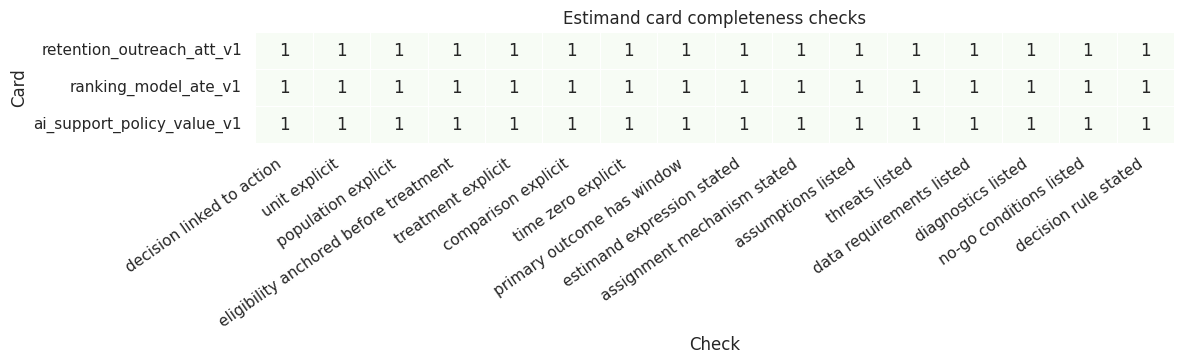

In [40]:
quality_matrix = pd.DataFrame(
    {card.card_id: score_estimand_card(card) for card in estimand_cards}
).T.astype(int)

plt.figure(figsize=(12, 3.8))
sns.heatmap(quality_matrix, annot=True, cbar=False, cmap='Greens', linewidths=0.5, linecolor='white')
plt.title('Estimand card completeness checks')
plt.xlabel('Check')
plt.ylabel('Card')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


This visual check catches patterns that an average score would flatten. For Auditing Estimand Cards, look for where groups separate, where curves bend, or where the tails behave differently. Use those features to decide what needs modeling attention and what needs operational attention.


## 10. What a Weak Estimand Card Looks Like


In [41]:
# Section focus: 10. What a Weak Estimand Card Looks Like.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

weak_card = EstimandCard.model_validate(
    {
        'card_id': 'ai_support_weak_v1',
        'stakeholder_question': 'Did AI help support?',
        'decision': 'Decide whether AI is good.',
        'unit': 'users or tickets or queues',
        'target_population': 'support data',
        'eligibility_rule': 'not specified',
        'treatment': 'AI',
        'comparison': 'before AI',
        'time_zero': 'launch',
        'primary_outcome': {
            'name': 'success',
            'measurement': 'support got better',
            'window': 'not specified',
            'direction': 'higher is better',
            'guardrail': False,
        },
        'guardrail_outcomes': [],
        'estimand_type': 'ATE',
        'estimand_expression': 'effect of AI',
        'identification_strategy': 'compare before and after',
        'assignment_mechanism': 'not specified',
        'required_assumptions': ['things are comparable'],
        'threats_to_validity': ['bias'],
        'data_requirements': ['support data'],
        'diagnostics': ['check data'],
        'no_go_conditions': [],
        'decision_rule': 'launch if better',
    }
)

smart_display(weak_card)


EstimandCard(card_id='ai_support_weak_v1', stakeholder_question='Did AI help support?', decision='Decide whether AI is good.', unit='users or tickets or queues', target_population='support data', eligibility_rule='not specified', treatment='AI', comparison='before AI', time_zero='launch', primary_outcome=OutcomeSpec(name='success', measurement='support got better', window='not specified', direction='higher is better', guardrail=False), guardrail_outcomes=[], estimand_type='ATE', estimand_expression='effect of AI', identification_strategy='compare before and after', assignment_mechanism='not specified', required_assumptions=['things are comparable'], threats_to_validity=['bias'], data_requirements=['support data'], diagnostics=['check data'], no_go_conditions=[], decision_rule='launch if better')

The metric result should be read as an operating tradeoff. In What a Weak Estimand Card Looks Like, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The metric matters once it changes a cost tradeoff, risk tolerance, threshold, or stakeholder action.


In [42]:
# Section focus: 10. What a Weak Estimand Card Looks Like.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def audit_estimand_card(card):
    """Carry out the audit estimand card step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    card : object
        Structured estimand or design card being generated, checked, or displayed.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    issues = []
    if ' or ' in card.unit.lower():
        issues.append(('unit', 'The unit mixes multiple possible objects. Pick one analysis unit.'))
    if card.eligibility_rule.lower() in {'not specified', 'unknown', 'n/a'}:
        issues.append(('eligibility', 'Eligibility must be defined before treatment.'))
    if card.primary_outcome.window.lower() in {'not specified', 'unknown', 'n/a'}:
        issues.append(('outcome window', 'The outcome needs a measurement window.'))
    if len(card.required_assumptions) < 2:
        issues.append(('assumptions', 'The card hides the assumptions needed for causal interpretation.'))
    if len(card.threats_to_validity) < 2:
        issues.append(('threats', 'The card needs specific threats, not generic bias language.'))
    if len(card.diagnostics) < 2:
        issues.append(('diagnostics', 'The card needs concrete diagnostics tied to the design.'))
    if len(card.no_go_conditions) == 0:
        issues.append(('no-go conditions', 'The team should agree on conditions that invalidate or pause the analysis.'))
    if 'before' in card.comparison.lower() and 'after' not in card.comparison.lower():
        issues.append(('comparison', 'A before-only comparison is usually underspecified and vulnerable to time trends.'))
    return pd.DataFrame(issues, columns=['area', 'issue'])


audit_estimand_card(weak_card)


,area,issue
0,unit,The unit mixes multiple possible objects. Pick one analysis unit.
1,eligibility,Eligibility must be defined before treatment.
2,outcome window,The outcome needs a measurement window.
3,assumptions,The card hides the assumptions needed for causal interpretation.
4,threats,"The card needs specific threats, not generic bias language."
5,diagnostics,The card needs concrete diagnostics tied to the design.
6,no-go conditions,The team should agree on conditions that invalidate or pause the analysis.
7,comparison,A before-only comparison is usually underspecified and vulnerable to time trends.


This table gives the quantitative checkpoint for What a Weak Estimand Card Looks Like. The row that changes an operating choice deserves the most attention. When gaps or rankings look unstable, the next step is a diagnostic check rather than immediate deployment.


## 11. AI-Assisted Drafting Pattern

A good prompt asks the model to draft a reviewable artifact, not to answer the effect question. It should also tell the model what schema it must satisfy.

The default path below uses deterministic fallback JSON so the notebook renders on GitHub Pages without loading local models. Set `RUN_LIVE_LOCAL_LLM = True` when working interactively on the GPU machine.


In [43]:
# Section focus: 11. AI-Assisted Drafting Pattern.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

from pathlib import Path
import sys


def find_project_root(start=None):
    """Carry out the find project root step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    start : object
        Starting index, time, or location for the simulated event window.
    
    Returns
    -------
    object
        Intermediate result produced by the find project root calculation and reused by later cells.
    """
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    DEFAULT_MODELS_TO_COMPARE,
    build_chat_inputs,
    clean_generated_text,
    clear_loaded_model_cache,
    decode_generated_response,
    format_chat_prompt,
    get_device,
    has_package,
    load_local_model as _shared_load_local_model,
    local_chat as _shared_local_chat,
    move_inputs_to_model_device,
    prepare_chat_inputs,
    set_generation_seed,
)

DEVICE = get_device()


def load_local_model(model_id=MODEL_ID):
    """Carry out the load local model step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the load local model workflow.
    """
    return _shared_load_local_model(model_id)


def decode_generated_text(tokenizer, generated, prompt_token_count, model_id=MODEL_ID):
    """Carry out the decode generated text step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    tokenizer : object
        Tokenizer paired with the local language model for prompt encoding and decoding.
    generated : object
        Rate or probability parameter controlling this calculation.
    prompt_token_count : object
        Prompt text sent to the local language model in the live experiment.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the decode generated text workflow.
    """
    return decode_generated_response(tokenizer, generated, prompt_token_count, model_id=model_id)


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local chat step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local chat calculation and reused by later cells.
    """
    enabled = globals().get('RUN_LIVE_LOCAL_LLM', globals().get('RUN_LOCAL_LLM', True))
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=enabled,
    )


def local_generate(user_message, system_message=None, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local generate step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local generate calculation and reused by later cells.
    """
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=MODEL_ID,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=globals().get('RUN_LOCAL_LLM', globals().get('RUN_LIVE_LOCAL_LLM', True)),
    )


In [44]:
# Section focus: 11. AI-Assisted Drafting Pattern.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYSTEM_DESIGN_MESSAGE = textwrap.dedent(
    '''
    You are a careful causal inference assistant.
    Draft estimand cards and causal design documents.
    Do not answer whether the treatment worked.
    Do not invent missing operational details.
    Return valid JSON only when asked for JSON.
    '''
).strip()

ESTIMAND_CARD_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Draft an estimand card for this causal question.

    Case ID: {card_id}
    Stakeholder question: {stakeholder_question}
    Decision: {decision}
    Unit hint: {unit}
    Treatment hint: {treatment}
    Comparison hint: {comparison}
    Outcome hint: {outcome}
    Estimand type hint: {estimand_type}
    Estimand expression hint: {estimand_expression}
    Assignment mechanism hint: {assignment_mechanism}

    Return valid JSON only, with exactly these keys:
    card_id, stakeholder_question, decision, unit, target_population, eligibility_rule,
    treatment, comparison, time_zero, primary_outcome, guardrail_outcomes, estimand_type,
    estimand_expression, identification_strategy, assignment_mechanism, required_assumptions,
    threats_to_validity, data_requirements, diagnostics, no_go_conditions, decision_rule.

    estimand_type must be exactly one of: ATE, ATT, ATC, CATE, policy value, LATE, event-study effect.
    primary_outcome must be an object with keys: name, measurement, window, direction, guardrail.
    primary_outcome.guardrail must be a boolean, not an object.
    treatment and comparison must be strings, not objects.
    guardrail_outcomes must be an array of outcome objects with the same keys.
    required_assumptions, threats_to_validity, data_requirements, diagnostics, and no_go_conditions must be arrays of strings.
    Use the Case ID exactly as card_id.
    Do not answer whether the intervention worked.
    '''
).strip()

FALLBACK_CARD_JSON_BY_ID = {card.card_id: json.dumps(card.model_dump(), indent=2) for card in estimand_cards}


def prompt_from_card(card):
    """Carry out the prompt from card step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    card : object
        Structured estimand or design card being generated, checked, or displayed.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the prompt from card workflow.
    """
    return ESTIMAND_CARD_PROMPT_TEMPLATE.format(
        card_id=card.card_id,
        stakeholder_question=card.stakeholder_question,
        decision=card.decision,
        unit=card.unit,
        treatment=card.treatment,
        comparison=card.comparison,
        outcome=card.primary_outcome.name,
        estimand_type=card.estimand_type,
        estimand_expression=card.estimand_expression,
        assignment_mechanism=card.assignment_mechanism,
    )


def causal_design_llm(card, model_id=MODEL_ID):
    """Carry out the causal design llm step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    card : object
        Structured estimand or design card being generated, checked, or displayed.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the causal design llm workflow for later analysis.
    """
    prompt = prompt_from_card(card)
    if RUN_LIVE_LOCAL_LLM:
        return local_chat(prompt, system_message=SYSTEM_DESIGN_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
    return FALLBACK_CARD_JSON_BY_ID[card.card_id]


raw_estimand_card = causal_design_llm(estimand_cards[2])
print(raw_estimand_card[:1400])


```json
{
 "card_id": "ai_support_policy_value_v1",
 "stakeholder_question": "Should we roll out the AI support assistant to all queues?",
 "decision": "Choose whether to expand assistant coverage and under what guardrails.",
 "unit": "support queue-day",
 "target_population": "All support queues that meet operational readiness and have high volume",
 "eligibility_rule": "Queues must demonstrate high volume of tickets and be deemed operationally ready by IT.",
 "treatment": "assistant enabled for triage and first-draft responses",
 "comparison": "standard support workflow without assistant enablement",
 "time_zero": "The start date of the rollout period",
 "primary_outcome": {
 "name": "ticket resolution workload",
 "measurement": "number of tickets resolved per day",
 "window": "30 days post-implementation",
 "direction": "decrease",
 "guardrail": false
 },
 "guardrail_outcomes": [
 {
 "name": "escalation rate",
 "measurement": "percentage of tickets escalated to higher levels of supp

AI-Assisted Drafting Pattern should make the design easier to audit, not easier to hand-wave.


## 12. Parsing, Repairing, and Validating AI Drafts


In [45]:
# Section focus: 12. Parsing, Repairing, and Validating AI Drafts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

LIST_FIELDS = [
    'guardrail_outcomes',
    'required_assumptions',
    'threats_to_validity',
    'data_requirements',
    'diagnostics',
    'no_go_conditions',
]
STRING_FIELDS = [
    'card_id',
    'stakeholder_question',
    'decision',
    'unit',
    'target_population',
    'eligibility_rule',
    'treatment',
    'comparison',
    'time_zero',
    'estimand_type',
    'estimand_expression',
    'identification_strategy',
    'assignment_mechanism',
    'decision_rule',
]
VALID_ESTIMAND_TYPES = {'ATE', 'ATT', 'ATC', 'CATE', 'policy value', 'LATE', 'event-study effect'}


def extract_json_object(text):
    """Extract the first JSON object from a model response for structured validation.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the json object workflow.
    """
    cleaned = clean_generated_text(text)
    cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned.strip())
    cleaned = re.sub(r'\s*```$', '', cleaned.strip())
    start = cleaned.find('{')
    end = cleaned.rfind('}')
    if start == -1 or end == -1 or end <= start:
        return None
    return cleaned[start : end + 1]


def split_list_like_string(value):
    """Carry out the split list like string step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    value = clean_generated_text(value)
    if not value:
        return []
    if ';' in value or '\n' in value:
        pieces = re.split(r';|\n', value)
    elif re.search(r',\s+(?:and\s+)?[a-zA-Z]', value):
        pieces = re.split(r',\s*', value)
    else:
        pieces = [value]
    return [piece.strip(' .-') for piece in pieces if piece.strip(' .-')]


def dict_to_readable_text(value):
    """Carry out the dict to readable text step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the dict to readable text workflow.
    """
    if not isinstance(value, dict):
        return clean_generated_text(value)
    preferred_keys = ['name', 'description', 'value', 'label', 'definition', 'rule']
    pieces = [clean_generated_text(value[key]) for key in preferred_keys if key in value and value[key] not in [None, '']]
    if pieces:
        return ': '.join(pieces[:2]) if len(pieces) > 1 else pieces[0]
    return '; '.join(f'{key}: {clean_generated_text(val)}' for key, val in value.items())


def coerce_string_fields(data):
    """Carry out the coerce string fields step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    data : object
        Input data set used by this step of the notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the coerce string fields calculation and reused by later cells.
    """
    notes = []
    for field in STRING_FIELDS:
        value = data.get(field)
        if isinstance(value, dict):
            data[field] = dict_to_readable_text(value)
            notes.append(f'coerced {field} from object to string')
        elif isinstance(value, list):
            data[field] = '; '.join(dict_to_readable_text(item) for item in value)
            notes.append(f'coerced {field} from list to string')
        elif value is not None and not isinstance(value, str):
            data[field] = str(value)
            notes.append(f'coerced {field} from {type(value).__name__} to string')
    return notes


def normalize_outcome_spec(value, default_name='outcome'):
    """Carry out the normalize outcome spec step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    default_name : object
        The default name setting that controls the normalize outcome spec calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    notes = []
    if isinstance(value, str):
        value = {
            'name': value,
            'measurement': value,
            'window': 'not specified',
            'direction': 'not specified',
            'guardrail': False,
        }
        notes.append('coerced outcome from string to object')
    elif not isinstance(value, dict):
        value = {
            'name': default_name,
            'measurement': clean_generated_text(value),
            'window': 'not specified',
            'direction': 'not specified',
            'guardrail': False,
        }
        notes.append(f'coerced outcome from {type(value).__name__} to object')
    else:
        value = dict(value)

    value.setdefault('name', default_name)
    value.setdefault('measurement', dict_to_readable_text(value.get('name', default_name)))
    value.setdefault('window', 'not specified')
    value.setdefault('direction', 'not specified')
    value.setdefault('guardrail', False)

    if isinstance(value.get('guardrail'), dict):
        value['guardrail'] = True
        notes.append('coerced outcome guardrail object to boolean True')
    elif isinstance(value.get('guardrail'), str):
        value['guardrail'] = value['guardrail'].strip().lower() in {'true', 'yes', 'y', '1', 'guardrail'}
        notes.append('coerced outcome guardrail string to boolean')

    for key in ['name', 'measurement', 'window', 'direction']:
        if isinstance(value.get(key), dict):
            value[key] = dict_to_readable_text(value[key])
            notes.append(f'coerced outcome.{key} from object to string')
        elif isinstance(value.get(key), list):
            value[key] = '; '.join(dict_to_readable_text(item) for item in value[key])
            notes.append(f'coerced outcome.{key} from list to string')
        elif value.get(key) is not None and not isinstance(value.get(key), str):
            value[key] = str(value[key])
            notes.append(f'coerced outcome.{key} to string')

    return value, notes


def normalize_guardrail_outcomes(value):
    """Carry out the normalize guardrail outcomes step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    notes = []
    if value is None:
        return [], ['coerced guardrail_outcomes from null to empty list']
    if isinstance(value, str):
        value = split_list_like_string(value)
        notes.append('coerced guardrail_outcomes from string to list')
    elif isinstance(value, dict):
        value = [value]
        notes.append('coerced guardrail_outcomes from object to list')
    elif not isinstance(value, list):
        value = [value]
        notes.append(f'coerced guardrail_outcomes from {type(value).__name__} to list')

    normalized = []
    for idx, item in enumerate(value):
        outcome, outcome_notes = normalize_outcome_spec(item, default_name=f'guardrail outcome {idx + 1}')
        outcome['guardrail'] = True
        normalized.append(outcome)
        notes.extend(f'guardrail_outcomes[{idx}]: {note}' for note in outcome_notes)
    return normalized, notes


def normalize_estimand_type(value):
    """Carry out the normalize estimand type step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    if not isinstance(value, str):
        return value, []
    cleaned = value.strip()
    lower = cleaned.lower()
    compact = re.sub(r'[^a-z0-9]+', ' ', lower).strip()
    mapping = {
        'average treatment effect': 'ATE',
        'ate': 'ATE',
        'average treatment effect on the treated': 'ATT',
        'att': 'ATT',
        'average treatment effect on treated': 'ATT',
        'average treatment effect on the controls': 'ATC',
        'average treatment effect on controls': 'ATC',
        'atc': 'ATC',
        'conditional average treatment effect': 'CATE',
        'cate': 'CATE',
        'policy value': 'policy value',
        'policy_value': 'policy value',
        'local average treatment effect': 'LATE',
        'late': 'LATE',
        'event study effect': 'event-study effect',
        'event-study effect': 'event-study effect',
    }
    if cleaned in VALID_ESTIMAND_TYPES:
        return cleaned, []
    if lower in mapping:
        return mapping[lower], [f'normalized estimand_type from {value!r} to {mapping[lower]!r}']
    if compact in mapping:
        return mapping[compact], [f'normalized estimand_type from {value!r} to {mapping[compact]!r}']

    parenthetical = re.search(r'\((ate|att|atc|cate|late)\)', lower)
    if parenthetical:
        normalized = parenthetical.group(1).upper()
        return normalized, [f'normalized estimand_type from {value!r} to {normalized!r}']

    if 'policy' in lower:
        return 'policy value', [f'normalized estimand_type from {value!r} to policy value']
    if 'treated' in lower:
        return 'ATT', [f'normalized estimand_type from {value!r} to ATT']
    if 'control' in lower and 'average treatment effect' in lower:
        return 'ATC', [f'normalized estimand_type from {value!r} to ATC']
    if 'conditional' in lower or 'heterogeneous' in lower:
        return 'CATE', [f'normalized estimand_type from {value!r} to CATE']
    if 'local' in lower or 'instrument' in lower or 'complier' in lower:
        return 'LATE', [f'normalized estimand_type from {value!r} to LATE']
    if 'event' in lower and 'study' in lower:
        return 'event-study effect', [f'normalized estimand_type from {value!r} to event-study effect']
    if 'average treatment effect' in lower:
        return 'ATE', [f'normalized estimand_type from {value!r} to ATE']
    return cleaned, []


def coerce_estimand_card(candidate):
    """Carry out the coerce estimand card step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    candidate : object
        Candidate action, variable, model, or explanation being compared.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    data = json.loads(candidate)
    notes = []

    notes.extend(coerce_string_fields(data))

    primary_outcome, outcome_notes = normalize_outcome_spec(data.get('primary_outcome', {}), default_name='primary outcome')
    data['primary_outcome'] = primary_outcome
    notes.extend(f'primary_outcome: {note}' for note in outcome_notes)

    guardrails, guardrail_notes = normalize_guardrail_outcomes(data.get('guardrail_outcomes', []))
    data['guardrail_outcomes'] = guardrails
    notes.extend(guardrail_notes)

    for field in ['required_assumptions', 'threats_to_validity', 'data_requirements', 'diagnostics', 'no_go_conditions']:
        value = data.get(field, [])
        if isinstance(value, list):
            normalized_items = []
            for item in value:
                normalized_items.append(dict_to_readable_text(item) if isinstance(item, dict) else clean_generated_text(item))
            data[field] = [item for item in normalized_items if item]
        elif isinstance(value, str):
            data[field] = split_list_like_string(value)
            notes.append(f'coerced {field} from string to list')
        elif value is None:
            data[field] = []
            notes.append(f'coerced {field} from null to empty list')
        else:
            data[field] = [dict_to_readable_text(value)]
            notes.append(f'coerced {field} from {type(value).__name__} to list')

    normalized_type, type_notes = normalize_estimand_type(data.get('estimand_type', 'ATE'))
    data['estimand_type'] = normalized_type
    notes.extend(type_notes)

    return json.dumps(data), notes


def parse_estimand_card(raw_output):
    """Carry out the parse estimand card step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    candidates = [clean_generated_text(raw_output)]
    extracted = extract_json_object(raw_output)
    if extracted is not None and extracted not in candidates:
        candidates.append(extracted)

    errors = []
    for candidate in candidates:
        try:
            return EstimandCard.model_validate_json(candidate), candidate, errors
        except ValidationError as error:
            errors.append(error.errors()[0]['msg'])
        except ValueError as error:
            errors.append(str(error).splitlines()[0])

        try:
            repaired_candidate, repair_notes = coerce_estimand_card(candidate)
            return EstimandCard.model_validate_json(repaired_candidate), repaired_candidate, errors + repair_notes
        except (TypeError, json.JSONDecodeError, ValidationError) as error:
            errors.append(str(error).splitlines()[0])

    raise ValueError(f'No valid EstimandCard found. Parser errors: {errors}')


parsed_ai_card, json_used, parser_notes = parse_estimand_card(raw_estimand_card)
if parser_notes:
    print('Parser notes:')
    print(parser_notes)

smart_display(parsed_ai_card)


Parser notes:
['Invalid JSON: expected value at line 1 column 1', 'Expecting value: line 1 column 1 (char 0)']


EstimandCard(card_id='ai_support_policy_value_v1', stakeholder_question='Should we roll out the AI support assistant to all queues?', decision='Choose whether to expand assistant coverage and under what guardrails.', unit='support queue-day', target_population='All support queues that meet operational readiness and have high volume', eligibility_rule='Queues must demonstrate high volume of tickets and be deemed operationally ready by IT.', treatment='assistant enabled for triage and first-draft responses', comparison='standard support workflow without assistant enablement', time_zero='The start date of the rollout period', primary_outcome=OutcomeSpec(name='ticket resolution workload', measurement='number of tickets resolved per day', window='30 days post-implementation', direction='decrease', guardrail=False), guardrail_outcomes=[OutcomeSpec(name='escalation rate', measurement='percentage of tickets escalated to higher levels of support', window='30 days post-implementation', direction

Parsing, Repairing, and Validating AI Drafts is a model-behavior check. The answer should be grounded before it tries to be persuasive, and failures should point to a specific repair in the workflow.


## 13. Review the AI-Drafted Card


In [46]:
parsed_checks = score_estimand_card(parsed_ai_card)
parsed_review = pd.DataFrame(
    [{'check': key, 'passed': value} for key, value in parsed_checks.items()]
)

smart_display(parsed_review)


,check,passed
0,decision linked to action,True
1,unit explicit,True
2,population explicit,True
3,eligibility anchored before treatment,True
4,treatment explicit,True
5,comparison explicit,True
6,time zero explicit,True
7,primary outcome has window,True
8,estimand expression stated,True
9,assignment mechanism stated,True


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Review the AI-Drafted Card. The interesting row is the one that would change the next diagnostic, even when it is not the largest number.


### Semantic Review: Guardrail Direction and Business Meaning

The structural review above checks whether required fields are present. It does not know whether the content makes business sense.

For example, an AI-drafted card might pass the schema while saying that escalation rate should increase or customer satisfaction should decrease. Those are not parser errors. They are semantic review errors. This is exactly why the analyst remains responsible for judging the design artifact after validation.


In [47]:
# Section focus: Semantic Review: Guardrail Direction and Business Meaning.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def audit_guardrail_direction(card):
    """Carry out the audit guardrail direction step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    card : object
        Structured estimand or design card being generated, checked, or displayed.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    lower_is_better_terms = [
        'churn', 'cost', 'latency', 'error', 'failure', 'reopen', 'escalation',
        'complaint', 'defect', 'risk', 'workload', 'ticket volume', 'handle time',
        'hallucination', 'toxicity', 'refund', 'fraud', 'downtime', 'backlog',
    ]
    higher_is_better_terms = [
        'satisfaction', 'csat', 'quality', 'conversion', 'retention', 'revenue',
        'accuracy', 'resolution', 'success', 'trust', 'helpfulness', 'nps',
    ]
    decrease_words = {'decrease', 'lower', 'lower is better', 'reduce', 'reduction', 'down'}
    increase_words = {'increase', 'higher', 'higher is better', 'improve', 'up'}

    rows = []
    for outcome in [card.primary_outcome] + card.guardrail_outcomes:
        name_measure = f'{outcome.name} {outcome.measurement}'.lower()
        direction = outcome.direction.strip().lower()
        expected = 'review manually'
        issue = ''

        if any(term in name_measure for term in lower_is_better_terms):
            expected = 'lower is better'
            if direction in increase_words or direction == 'increase':
                issue = 'direction likely reversed for a harm/burden metric'
        elif any(term in name_measure for term in higher_is_better_terms):
            expected = 'higher is better'
            if direction in decrease_words or direction == 'decrease':
                issue = 'direction likely reversed for a benefit/quality metric'

        rows.append(
            {
                'outcome': outcome.name,
                'guardrail': outcome.guardrail,
                'stated_direction': outcome.direction,
                'expected_direction': expected,
                'semantic_issue': issue or 'none flagged',
            }
        )

    return pd.DataFrame(rows)


guardrail_direction_audit = audit_guardrail_direction(parsed_ai_card)
smart_display(guardrail_direction_audit)


,outcome,guardrail,stated_direction,expected_direction,semantic_issue
0,ticket resolution workload,False,decrease,lower is better,none flagged
1,escalation rate,True,increase,lower is better,direction likely reversed for a harm/burden metric
2,customer satisfaction score,True,decrease,higher is better,direction likely reversed for a benefit/quality metric


For Semantic Review: Guardrail Direction and Business Meaning, weak output is useful only if it tells us which part of the workflow needs a stronger check.


### How to Use This Audit

The audit is intentionally simple. It is not a replacement for domain review. It is a tripwire that catches common LLM mistakes where the model fills the schema but reverses the meaning of a metric.

If this table flags an issue, the analyst should edit the card or ask the model for a constrained repair such as:

> Keep the same card, but correct the direction fields for guardrail outcomes. Do not change the treatment, comparison, population, or estimand.

This is a different kind of repair from JSON parsing. JSON repair fixes machine readability. Semantic repair fixes the causal design artifact.


In [48]:
smart_display(Markdown(render_estimand_card(parsed_ai_card)))


### Estimand Card: `ai_support_policy_value_v1`

**Stakeholder question.** Should we roll out the AI support assistant to all queues?

**Decision.** Choose whether to expand assistant coverage and under what guardrails.

**Unit and population.** The unit is `support queue-day`. The target population is All support queues that meet operational readiness and have high volume.

**Eligibility rule.** Queues must demonstrate high volume of tickets and be deemed operationally ready by IT.

**Treatment.** assistant enabled for triage and first-draft responses

**Comparison.** standard support workflow without assistant enablement

**Time zero.** The start date of the rollout period

**Primary outcome.** ticket resolution workload: number of tickets resolved per day. Window: 30 days post-implementation. Direction: decrease.

**Guardrail outcomes.**
- **escalation rate** (30 days post-implementation): percentage of tickets escalated to higher levels of support; direction: increase
- **customer satisfaction score** (30 days post-implementation): average CSAT score from customer feedback; direction: decrease

**Estimand.** policy value: `E[Y under assistant-rollout policy] - E[Y under no-assistant policy] for eligible queue-days`

**Identification strategy.** Difference-in-differences

**Assignment mechanism.** deployment prioritized by operational readiness and queue volume

**Required assumptions.**
- No interference between units (queues)
- Stable unit characteristics over time
- Random assignment to treatment and control groups

**Threats to validity.**
- Selection bias due to non-random assignment
- Confounding variables not accounted for
- Measurement error in outcomes

**Data requirements.**
- Daily ticket resolution data
- Operational readiness assessments
- Customer satisfaction survey results

**Diagnostics.**
- Check for parallel trends assumption using pre-treatment period
- Validate that treatment and control groups are similar at baseline

**No-go conditions.**
- Insufficient data on operational readiness
- High risk of significant negative impact on escalation rates or customer satisfaction

**Decision rule.** Roll out the AI support assistant if the estimated policy value is positive and within acceptable guardrails.

Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in How to Use This Audit. A large difference deserves a closer look before it becomes an operating rule.


## 14. Optional All-Model Comparison

Because these are live local model calls, the exact ranking may change across model versions, package versions, seeds, tokenizer behavior, prompt wording, and reruns. The durable lesson is the evaluation pattern, not the leaderboard. Use the table as evidence about the model in this setting.

As in Notebook 03, the model comparison separates structured-output reliability from causal-design quality.

The default public render does not run the comparison. For an interactive GPU run, set:

```python
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
```

The comparison uses all available local models in `MODELS_TO_COMPARE`.

In [49]:
# Section focus: 14. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

COMPARISON_CARDS = estimand_cards

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_design_score', 'failure_types'
]

CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'card_id', 'status', 'schema_valid', 'repair_used',
    'repair_stage', 'error_type', 'design_score', 'max_design_score', 'design_score_share', 'error'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required EstimandCard JSON schema.
    Convert the previous answer into valid JSON only.

    Do not add new causal claims.
    Do not answer whether the treatment worked.
    Preserve the card_id when possible.
    All list fields must be JSON arrays.
    primary_outcome must be an object with name, measurement, window, direction, and guardrail.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be a valid' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_extra_text'
    return 'other_structured_output_error'


def build_schema_repair_prompt(raw_output, error_message):
    """Build the schema repair prompt object used in the 04. Estimand Cards and Causal Design Documents analysis.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    error_message : object
        Error text captured so the notebook can classify and explain the failure.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the schema repair prompt workflow.
    """
    return SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
        raw_output=clean_generated_text(raw_output)[:5000],
        error_message=clean_generated_text(error_message)[:1200],
    )


def parse_or_repair_estimand_card(raw_output, model_id):
    """Carry out the parse or repair estimand card step used in the 04. Estimand Cards and Causal Design Documents workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')

    try:
        parsed, parsed_json, parser_notes = parse_estimand_card(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': parser_notes,
            'repair_used': bool(parser_notes),
            'repair_stage': 'parser' if parser_notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise

        repair_prompt = build_schema_repair_prompt(raw_output, repr(first_error))
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_DESIGN_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, parser_notes = parse_estimand_card(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + parser_notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def evaluate_model_on_estimand_cards(label, model_id, role, cards=COMPARISON_CARDS):
    """Evaluate model on estimand cards for the 04. Estimand Cards and Causal Design Documents decision workflow.
    
    Parameters
    ----------
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    role : object
        Workflow role assigned to an agent, variable, or review component.
    cards : object
        The cards setting that controls the model on estimand cards calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    artifacts = {}

    for card in cards:
        raw_output = ''
        repaired_raw_output = ''
        parsed_json = ''
        parser_notes = []
        checks = {}
        error = ''
        error_type = ''
        schema_valid = False
        repair_used = False
        repair_stage = 'none'
        design_score = np.nan
        max_design_score = 16

        try:
            raw_output = local_chat(
                prompt_from_card(card),
                system_message=SYSTEM_DESIGN_MESSAGE,
                model_id=model_id,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
            )
            parse_result = parse_or_repair_estimand_card(raw_output, model_id)
            parsed = parse_result['parsed']
            parsed_json = parse_result['parsed_json']
            parser_notes = parse_result['parser_notes']
            repair_used = parse_result['repair_used']
            repair_stage = parse_result['repair_stage']
            repaired_raw_output = parse_result['repaired_raw_output']
            checks = score_estimand_card(parsed)
            design_score = int(sum(checks.values()))
            max_design_score = len(checks)
            status = 'ok_after_repair' if repair_used else 'ok'
            schema_valid = True
            error_type = 'none'
        except Exception as exc:
            status = 'schema_error'
            error = repr(exc)[:500]
            error_type = classify_structured_output_failure(exc)

        rows.append(
            {
                'label': label,
                'model_id': model_id,
                'role': role,
                'card_id': card.card_id,
                'status': status,
                'schema_valid': schema_valid,
                'repair_used': repair_used,
                'repair_stage': repair_stage,
                'error_type': error_type,
                'design_score': design_score,
                'max_design_score': max_design_score,
                'design_score_share': design_score / max_design_score if pd.notna(design_score) else 0.0,
                'error': error,
            }
        )
        artifacts[(label, card.card_id)] = {
            'raw_output': raw_output,
            'repaired_raw_output': repaired_raw_output,
            'parsed_json': parsed_json,
            'parser_notes': parser_notes,
            'checks': checks,
        }

    clear_loaded_model_cache()
    return rows, artifacts


def summarize_model_results(case_results):
    """Summarize model results for the 04. Estimand Cards and Causal Design Documents analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)

    model_summary = (
        case_results.groupby(['label', 'model_id', 'role'], dropna=False)
        .agg(
            cases=('card_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_design_score=('design_score_share', lambda s: s.fillna(0).mean()),
            failure_types=('error_type', lambda s: ', '.join(sorted({str(x) for x in s if str(x) and str(x) != 'none'}))),
        )
        .reset_index()
    )
    model_summary['schema_reliability'] = model_summary['schema_valid_cases'] / model_summary['cases']
    return model_summary[SUMMARY_COLUMNS].sort_values(
        ['schema_reliability', 'mean_design_score', 'schema_repaired_cases'],
        ascending=[False, False, True],
    )


def run_all_model_estimand_comparison(models_to_compare=MODELS_TO_COMPARE):
    """Run the all model estimand comparison workflow for the 04. Estimand Cards and Causal Design Documents analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    if not RUN_LIVE_LOCAL_LLM:
        raise RuntimeError('Set RUN_LIVE_LOCAL_LLM = True before running the model comparison.')

    rows = []
    artifacts = {}
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        model_rows, model_artifacts = evaluate_model_on_estimand_cards(label, model_id, role)
        rows.extend(model_rows)
        artifacts.update(model_artifacts)

    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    model_summary = summarize_model_results(case_results)
    return case_results, model_summary, artifacts


if RUN_FULL_MODEL_COMPARISON:
    estimand_case_results, estimand_model_summary, estimand_artifacts = run_all_model_estimand_comparison()
else:
    estimand_model_summary = pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])
    estimand_model_summary['cases'] = len(COMPARISON_CARDS)
    estimand_model_summary['schema_valid_cases'] = np.nan
    estimand_model_summary['schema_repaired_cases'] = np.nan
    estimand_model_summary['schema_reliability'] = np.nan
    estimand_model_summary['mean_design_score'] = np.nan
    estimand_model_summary['failure_types'] = ''
    estimand_model_summary = estimand_model_summary[SUMMARY_COLUMNS]
    estimand_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    estimand_artifacts = {}
    smart_display(Markdown('All-model comparison is configured but not executed. Set `RUN_LIVE_LOCAL_LLM = True` and `RUN_FULL_MODEL_COMPARISON = True` in an interactive GPU session.'))

smart_display(estimand_model_summary)


Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_design_score,failure_types
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,3,3,3,1.000,1.000,
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,3,3,3,1.000,1.000,
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,3,3,2,1.000,0.979,
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,3,3,2,1.000,0.979,
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,3,3,3,1.000,0.979,
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,3,3,3,1.000,0.958,
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,3,1,1,0.333,0.333,invalid_json_or_extra_text
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,3,1,1,0.333,0.333,wrong_field_type_or_schema
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,3,0,0,0.000,0.000,"invalid_json_or_extra_text, wrong_field_type_or_schema"


For Optional All-Model Comparison, use the output to see whether the model respected the design contract or blurred it.


## 15. Human Review Checklist


| area | review question |
|---|---|
| decision | Would a decision-maker know what action this evidence will inform? |
| unit | Is there exactly one analysis unit? |
| population | Is the target population defined before treatment? |
| eligibility | Can eligibility be reconstructed from logs without using future information? |
| treatment | Is treatment observable and timestamped? |
| comparison | Is the counterfactual condition operationally meaningful? |
| time zero | Is follow-up anchored at a pre-treatment or assignment time? |
| outcome | Is the primary outcome measured consistently and after time zero? |
| guardrails | Could the primary outcome improve while the business gets worse? |
| guardrail directions | Do direction fields match whether each metric is a benefit or a harm? |
| estimand | Does the estimand type match the business decision? |
| assignment | Do we know how treatment was assigned or selected? |
| assumptions | Are assumptions specific enough to audit? |
| diagnostics | Are diagnostics tied to the identification strategy? |
| no-go | Has the team agreed on evidence that would pause the analysis? |


## 16. Common Estimand-Card Patterns


| project pattern | common estimand | decision-relevant question | main warning |
|---|---|---|---|
| Targeted retention program | ATT | Did the program help the accounts that were actually targeted? | unmeasured manager judgment and poor overlap |
| Randomized product experiment | ATE | What happens if the new experience becomes default for eligible traffic? | triggering mistakes, SRM, interference, guardrails |
| Personalized treatment rule | policy value | Which assignment policy produces the best expected outcome? | offline policy evaluation bias and support violations |
| Threshold eligibility rule | LATE or RD estimand | What is the effect near the threshold or among compliers? | manipulation around threshold and local interpretation |
| Staggered operational rollout | event-study effect or policy value | What changed after rollout relative to not-yet-treated units? | pre-trends, rollout targeting, concurrent process changes |


## 17. Key Takeaways

- An estimand card is the bridge between a causal question and an analysis plan.
- The card should specify unit, population, eligibility, treatment, comparison, time zero, outcome, estimand type, identification strategy, assumptions, diagnostics, and no-go conditions.
- ATE, ATT, CATE, policy value, and LATE answer different business questions.
- Simulation makes the distinction concrete: when treatment is targeted, ATT can differ meaningfully from ATE.
- AI can draft estimand cards quickly, but schema validation only checks structure. Human review still has to judge whether the design is causally credible.
- A card can pass schema validation while still having semantic mistakes, such as reversed guardrail directions.
- Future model comparisons should continue to report structured-output reliability separately from design quality.

The next notebook uses AI to brainstorm DAGs from a design brief while keeping variable roles and temporal ordering explicit.


## References

- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Imbens, G. W., & Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge University Press. [https://doi.org/10.1017/CBO9781139025751](https://doi.org/10.1017/CBO9781139025751)
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology*, 66(5), 688-701. [https://doi.org/10.1037/h0037350](https://doi.org/10.1037/h0037350)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
